In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
raw_path = Path("d:/bluestock_mf_capstone/data/raw")
processed_path = Path("d:/bluestock_mf_capstone/data/processed")

# Load required data
nav_data = pd.read_csv(processed_path / "02_nav_history_cleaned.csv")
fund_master = pd.read_csv(raw_path / "01_fund_master.csv")
transactions = pd.read_csv(processed_path / "08_investor_transactions_cleaned.csv")
perf = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
scorecard = pd.read_csv(processed_path / "fund_scorecard.csv")  # from Day 4
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")

print("All data loaded")

All data loaded


In [2]:
# Prepare daily returns
nav_pivot = nav_data.pivot(index='date', columns='amfi_code', values='nav')
returns = nav_pivot.pct_change().dropna()

# Compute VaR (5th percentile) and CVaR (mean of losses beyond VaR)
var_results = []
for code in returns.columns:
    daily_ret = returns[code].dropna()
    var_95 = np.percentile(daily_ret, 5)  # 95% VaR (5th percentile)
    cvar = daily_ret[daily_ret <= var_95].mean()
    var_results.append({
        'amfi_code': code,
        'VaR_95%': var_95,
        'CVaR': cvar
    })
var_df = pd.DataFrame(var_results)
# Merge with scheme names
fund_names = fund_master[['amfi_code', 'scheme_name']]
var_df = var_df.merge(fund_names, on='amfi_code', how='left')
var_df = var_df[['scheme_name', 'VaR_95%', 'CVaR']]
var_df = var_df.sort_values('VaR_95%')  # worst VaR first
print("Top 5 worst VaR (largest negative):")
print(var_df.head())
# Save
var_df.to_csv(processed_path / "var_cvar_report.csv", index=False)
print("Saved var_cvar_report.csv")

Top 5 worst VaR (largest negative):
                                       scheme_name   VaR_95%      CVaR
22       SBI Small Cap Fund - Direct Plan - Growth -0.026859 -0.032384
17          Axis Small Cap Fund - Regular - Growth -0.026188 -0.031667
4           ABSL Small Cap Fund - Regular - Growth -0.026021 -0.032459
11  Nippon India Small Cap Fund - Regular - Growth -0.025438 -0.032304
21      SBI Small Cap Fund - Regular Plan - Growth -0.024507 -0.030595
Saved var_cvar_report.csv


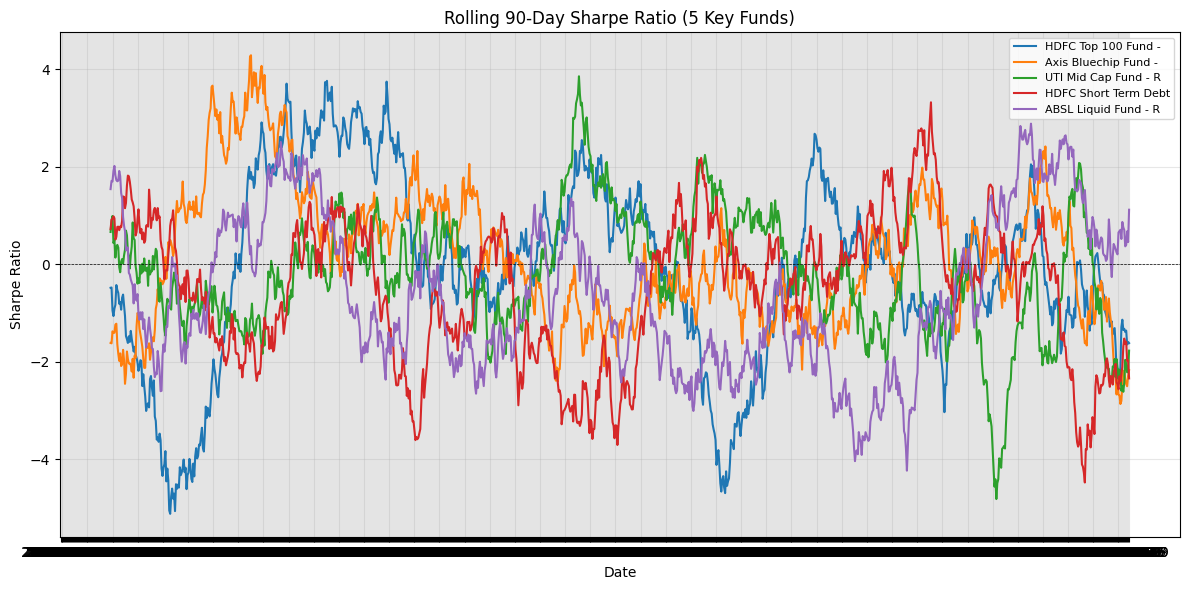

Saved rolling_sharpe_chart.png


In [3]:
# Pick 5 key funds (e.g., top 5 by AUM from scorecard)
top_funds = scorecard.sort_values('score_100', ascending=False).head(5)['scheme_name'].tolist()
# Map scheme_name to amfi_code
name_to_code = fund_master.set_index('scheme_name')['amfi_code'].to_dict()
rf_annual = 0.065
rf_daily = (1 + rf_annual) ** (1/252) - 1

plt.figure(figsize=(12, 6))
for scheme in top_funds:
    code = name_to_code.get(scheme)
    if code in returns.columns:
        fund_ret = returns[code].dropna()
        # Rolling 90-day Sharpe (annualized)
        roll_mean = fund_ret.rolling(90).mean()
        roll_std = fund_ret.rolling(90).std()
        roll_sharpe = (roll_mean - rf_daily) / roll_std * np.sqrt(252)
        plt.plot(roll_sharpe.index, roll_sharpe, label=scheme[:20])
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.title('Rolling 90-Day Sharpe Ratio (5 Key Funds)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(processed_path / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Saved rolling_sharpe_chart.png")

In [4]:
# Prepare transaction data with dates
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
# Get first transaction year per investor
first_year = transactions.groupby('investor_id')['transaction_date'].min().dt.year.reset_index()
first_year.columns = ['investor_id', 'cohort_year']
# Merge back
trans = transactions.merge(first_year, on='investor_id')
# For SIP amounts (transaction_type = 'SIP')
sip_trans = trans[trans['transaction_type'] == 'SIP']
cohort_stats = sip_trans.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    num_investors=('investor_id', 'nunique')
).reset_index()
# Top fund preference per cohort (most transacted scheme)
def top_fund(group):
    return group['amfi_code'].mode()[0] if not group['amfi_code'].mode().empty else None
top_fund_per_cohort = trans.groupby('cohort_year').apply(top_fund).reset_index()
top_fund_per_cohort.columns = ['cohort_year', 'top_fund_code']
# Merge with fund names
fund_code_name = fund_master[['amfi_code', 'scheme_name']].rename(columns={'amfi_code': 'top_fund_code'})
top_fund_per_cohort = top_fund_per_cohort.merge(fund_code_name, on='top_fund_code', how='left')
cohort_stats = cohort_stats.merge(top_fund_per_cohort[['cohort_year', 'scheme_name']], on='cohort_year', how='left')
cohort_stats.rename(columns={'scheme_name': 'top_fund_name'}, inplace=True)
print(cohort_stats)

   cohort_year  avg_sip_amount  total_invested  num_investors  \
0         2024    10996.885825       214978121           4624   
1         2025    13505.209581         2255370            138   

                                       top_fund_name  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [5]:
# For each investor, get all SIP transaction dates
sip_only = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_only = sip_only.sort_values(['investor_id', 'transaction_date'])
# Filter investors with at least 6 SIP transactions
investor_counts = sip_only['investor_id'].value_counts()
valid_investors = investor_counts[investor_counts >= 6].index
sip_filtered = sip_only[sip_only['investor_id'].isin(valid_investors)]

# Compute average gap between consecutive SIP dates
def avg_gap(group):
    dates = group['transaction_date'].sort_values()
    gaps = dates.diff().dt.days.dropna()
    return gaps.mean() if not gaps.empty else np.nan

avg_gaps = sip_filtered.groupby('investor_id').apply(avg_gap).reset_index()
avg_gaps.columns = ['investor_id', 'avg_gap_days']
# Flag at-risk (gap > 35 days)
avg_gaps['at_risk'] = avg_gaps['avg_gap_days'] > 35
continuity_rate = 1 - avg_gaps['at_risk'].mean()
print(f"Proportion of investors with avg SIP gap > 35 days: {avg_gaps['at_risk'].mean():.2%}")
print(f"SIP continuity rate (avg gap ≤ 35 days): {continuity_rate:.2%}")

Proportion of investors with avg SIP gap > 35 days: 97.80%
SIP continuity rate (avg gap ≤ 35 days): 2.20%


In [6]:
# Prepare fund risk grade and Sharpe ratio
risk_map = fund_master[['amfi_code', 'risk_category']].rename(columns={'risk_category': 'risk_grade'})
sharpe_data = scorecard[['scheme_name', 'sharpe_ratio']]
sharpe_data = sharpe_data.merge(fund_master[['scheme_name', 'amfi_code']], on='scheme_name')
sharpe_data = sharpe_data.merge(risk_map, on='amfi_code')
# Clean risk_grade: map to Low, Moderate, High
risk_mapping = {
    'Low': 'Low', 'Moderate': 'Moderate', 'High': 'High',
    'Low Risk': 'Low', 'Medium': 'Moderate', 'High Risk': 'High'
}
sharpe_data['risk_grade_clean'] = sharpe_data['risk_grade'].map(risk_mapping).fillna('Moderate')
# Recommender function
def recommend_funds(risk_appetite, top_n=3):
    filtered = sharpe_data[sharpe_data['risk_grade_clean'] == risk_appetite]
    recommended = filtered.sort_values('sharpe_ratio', ascending=False).head(top_n)
    return recommended[['scheme_name', 'sharpe_ratio', 'risk_grade_clean']]

# Example usage
print("Recommendation for Low risk appetite:")
print(recommend_funds('Low'))
print("\nRecommendation for Moderate risk appetite:")
print(recommend_funds('Moderate'))
print("\nRecommendation for High risk appetite:")
print(recommend_funds('High'))

Recommendation for Low risk appetite:
                                     scheme_name  sharpe_ratio  \
15      ICICI Pru Liquid Fund - Regular - Growth      0.904162   
11          Kotak Liquid Fund - Regular - Growth      0.304256   
7   SBI Magnum Gilt Fund - Regular Plan - Growth     -0.175723   

   risk_grade_clean  
15              Low  
11              Low  
7               Low  

Recommendation for Moderate risk appetite:
                                      scheme_name  sharpe_ratio  \
36  Mirae Asset Large Cap Fund - Regular - Growth      1.462504   
35         Kotak Flexicap Fund - Regular - Growth      1.319442   
30      SBI Bluechip Fund - Regular Plan - Growth      1.222947   

   risk_grade_clean  
36         Moderate  
35         Moderate  
30         Moderate  

Recommendation for High risk appetite:
                                      scheme_name  sharpe_ratio  \
31  Mirae Asset Tax Saver Fund - Regular - Growth      1.246344   
39       ICICI Pru Midcap Fund - R

In [8]:
# Save as scripts/recommender.py
recommender_code = '''
import pandas as pd
from pathlib import Path

def load_data():
    processed_path = Path("data/processed")
    raw_path = Path("data/raw")
    fund_master = pd.read_csv(raw_path / "01_fund_master.csv")
    scorecard = pd.read_csv(processed_path / "fund_scorecard.csv")
    risk_map = fund_master[['amfi_code', 'risk_category']].rename(columns={'risk_category': 'risk_grade'})
    sharpe_data = scorecard[['scheme_name', 'sharpe_ratio']]
    sharpe_data = sharpe_data.merge(fund_master[['scheme_name', 'amfi_code']], on='scheme_name')
    sharpe_data = sharpe_data.merge(risk_map, on='amfi_code')
    risk_mapping = {'Low': 'Low', 'Moderate': 'Moderate', 'High': 'High',
                    'Low Risk': 'Low', 'Medium': 'Moderate', 'High Risk': 'High'}
    sharpe_data['risk_grade_clean'] = sharpe_data['risk_grade'].map(risk_mapping).fillna('Moderate')
    return sharpe_data

def recommend_funds(risk_appetite, top_n=3):
    data = load_data()
    filtered = data[data['risk_grade_clean'] == risk_appetite]
    recommended = filtered.sort_values('sharpe_ratio', ascending=False).head(top_n)
    return recommended[['scheme_name', 'sharpe_ratio', 'risk_grade_clean']]

if __name__ == "__main__":
    print("Fund Recommender")
    print("Available risk appetites: Low, Moderate, High")
    appetite = input("Enter risk appetite: ")
    print(recommend_funds(appetite))
'''
with open("d:/bluestock_mf_capstone//scripts/recommender.py", "w") as f:
    f.write(recommender_code)
print("Saved recommender.py")

Saved recommender.py


In [12]:
# Calculate HHI per fund from portfolio holdings
# Portfolio columns: 'amfi_code', 'weight_pct' (percentage)
hhi_results = []
for scheme in portfolio['amfi_code'].unique():
    # Convert weights to decimals (e.g., 13.85 → 0.1385)
    weights = portfolio[portfolio['amfi_code'] == scheme]['weight_pct'] / 100
    hhi = (weights ** 2).sum()
    hhi_results.append({'amfi_code': scheme, 'HHI': hhi})

hhi_df = pd.DataFrame(hhi_results)

# Merge with fund_master to get scheme names
fund_names = fund_master[['amfi_code', 'scheme_name']]
hhi_df = hhi_df.merge(fund_names, on='amfi_code', how='left')
hhi_df = hhi_df[['scheme_name', 'HHI']].sort_values('HHI', ascending=False)

print("Top 5 most concentrated portfolios (high HHI):")
print(hhi_df.head())
print("\nBottom 5 most diversified portfolios (low HHI):")
print(hhi_df.tail())

Top 5 most concentrated portfolios (high HHI):
                                       scheme_name       HHI
19           Axis Bluechip Fund - Regular - Growth  0.206448
24          ABSL Small Cap Fund - Regular - Growth  0.200700
3        SBI Small Cap Fund - Direct Plan - Growth  0.174751
25      UTI Nifty 50 Index Fund - Regular - Growth  0.174709
12  Nippon India Large Cap Fund - Regular - Growth  0.168298

Bottom 5 most diversified portfolios (low HHI):
                                       scheme_name       HHI
22          Axis Small Cap Fund - Regular - Growth  0.109605
9        ICICI Pru Bluechip Fund - Direct - Growth  0.108674
14  Nippon India Small Cap Fund - Regular - Growth  0.108358
1         SBI Bluechip Fund - Direct Plan - Growth  0.108011
2       SBI Small Cap Fund - Regular Plan - Growth  0.107349
